# Naive Bayes
Bayesian statistics applied as a classification technique truly emerged in the 1960s to solve text information retrieval, though the underlying theory and early applications date back to the mid-1700s (Reverend Thomas Bayes). 

Naive Bayes is a generative statistical inference technique. Like other generative methods, it tries to estimate the Bayes optimal classifier by factoring the posterior into the likelihood and prior (see our repository's [README.md](../../../../README.md) and the classification [README.md](../../../README.md) for more). However, Naive Bayes takes this a step further by assuming its features are *class-conditionally independent*. This allows us to break down the Bayes optimal rule as follows:

$$
f(\vec{x}) = \text{argmax}_c (P(Y=y_c|\vec{x})) \\
P(Y=y_c|\vec{x}) = \frac{P(X=\vec{x}|y_c) \cdot P(y_c)}{P(\vec{x})} \\
P(X=\vec{x}|y_c) = P(x_1, x_2, ..., x_p | y_c) = \prod_{i=1}^p P(x_i|y_c)
$$

Here, we simply have to capture the independent class-conditional distributions for each feature individually and multiply them to estimate the joint distribution. In the real world, this is a heavy and often unrealistic bias, but it is computationally incredibly efficient.

Like our other generative methods, we can estimate the class prior $P(y_c)$ by its proportion in the training dataset. Since the marginal distribution of the sample $P(\vec{x})$ is a constant denominator across all classes, we can ignore it. Finally, by applying a log transformation (which is rank-preserving), we turn the multiplications into additions to prevent floating-point underflow and maintain computational integrity. This gives us our final, equivalent class score to optimize over:

$$
f(\vec{x}) = \text{argmax}_c \left( \log(P(y_c)) + \sum_{i=1}^p \log(P(x_i | y_c)) \right)
$$

In practice, we simply look at the data type of each individual feature to determine which likelihood distribution to apply. 

Because of our naive independence assumption, we don't have to calculate massive, multi-dimensional distributions. Instead:
*   For a **continuous feature**, we can assume it follows a single-variable (univariate) Gaussian distribution and compute its individual probability density $\text{pdf}_i(x_i)$.
*   For a **binary/boolean feature** (e.g., word presence), we use a simple Bernoulli probability $P(x_i | y_c)$.
*   For **count/frequency features** (e.g., word counts), we use a Multinomial probability.

Ultimately, we compute the log-likelihood for each feature independently, and simply sum them together along with the log of the class prior. This generates the final class score that we maximize to make our prediction.

For training we estimate the class specific distributions for each feature, then use those for inference.

### Guassian Features
The guassian distribution models continous random variables, and is common when measuring physical phenomena or asymptotic behavior of random variable parameters. For Naive Bayes we consider each continous random variable it's own class conditional gaussian:

$$
x \sim N(\mu, \sigma^2)
$$

It's likelihood is the following density function:

$$
\text{pdf}(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} e^{\frac{-1}{2\sigma^2} \cdot (x - \mu)^2}
$$

Using it in our classifier:

$$
f(x) = \text{argmax}_c (\frac{1}{\sqrt{2 \pi \sigma_c^2}} e^{\frac{-1}{2\sigma_c^2} \cdot (x - \mu_c)^2} \cdot P(y_c))
$$

Applying the rank perserving log for stability:

$$
f(x) = \text{argmax}_c (\log(\frac{1}{\sqrt{2 \pi \sigma_c^2}}) + \frac{-1}{2\sigma_c^2} \cdot (x - \mu_c)^2 + \log(P(y_c)))
$$

In [58]:
import numpy as np

class_1_data = np.random.normal(5, 3, (1000, 1))
class_0_data = np.random.normal(-5,1, (1000, 1))

dataset = np.concat([np.concat([class_0_data, np.zeros(shape=(1000,1))], axis=-1),np.concat([class_1_data, np.ones(shape=(1000,1))], axis=-1)], axis=0)

np.random.shuffle(dataset)

training_dataset = dataset[:int(dataset.shape[0]*.8)]
test_dataset = dataset[int(dataset.shape[0]*.8):]

len(test_dataset), len(training_dataset)

(400, 1600)

In [59]:
class NaiveBayesClassifierGaussianBinarySingleVariable:
    def __init__(self):
        self.label_0_mean = None
        self.label_1_mean = None
        self.label_0_var = None
        self.label_1_var = None
        self.label_1_prior = None
        self.label_0_prior = None

    def train(self, dataset):
        '''
        Assumes last column is binary label
        '''
        label_1_data = dataset[dataset[:, -1] == 1][:, :-1]
        label_0_data = dataset[dataset[:, -1] == 0][:, :-1]

        self.label_1_mean = label_1_data.mean(axis=0)
        self.label_0_mean = label_0_data.mean(axis=0)

        self.label_1_var = label_1_data.var(axis=0)
        self.label_0_var = label_0_data.var(axis=0)

        self.label_1_prior = len(label_1_data) / len(dataset)
        self.label_0_prior = len(label_0_data) / len(dataset)


    def predict(self, data):
        if self.label_0_mean is None:
            raise Exception("Cannot predict without training.")
        class_1_score = np.log( 1 / np.sqrt(2*np.pi * self.label_1_var)) - 1 / (2 * self.label_1_var) * (data - self.label_1_mean)**2 + np.log(self.label_1_prior)
        class_0_score = np.log( 1 / np.sqrt(2*np.pi * self.label_0_var)) - 1 / (2 * self.label_0_var) * (data - self.label_0_mean)**2 + np.log(self.label_0_prior)
        return (class_1_score > class_0_score).astype(int).reshape(-1)

guassian_classifer = NaiveBayesClassifierGaussianBinarySingleVariable()
guassian_classifer.train(training_dataset)
print(guassian_classifer.__dict__)
(guassian_classifer.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()

{'label_0_mean': array([-5.00379665]), 'label_1_mean': array([4.8722888]), 'label_0_var': array([0.98301315]), 'label_1_var': array([9.38446849]), 'label_1_prior': 0.499375, 'label_0_prior': 0.500625}


np.float64(0.99)

We were able to recover the original data producing parameters, and classify with the near (as good as our estimate) bayes optimal rule.

### Bernoulli Features
Bernoulli distribution models binary outcomes with a probability that its 1 (by convention), the alternative is always $1 - p$.
If a feature $X$ follows a Bernoulli distribution with probability $p$, we denote this as:
$$
X \sim \text{Bernoulli}(p)
$$

1. The Piecewise Form (Logical)
The most intuitive way to write this PMF is as a logical map, evaluating the two possible discrete outcomes:
$$
P(X=x) = \begin{cases} 
p & \text{if } x = 1 \\
1-p & \text{if } x = 0 
\end{cases}
$$

2. The Closed Form (Algebraic)
To use this in machine learning (specifically so we can apply a log transformation), we collapse the piecewise logic into a single, compact algebraic equation using exponents:
$$
P(X=x) = p^x(1-p)^{1-x}
$$


So plugging this into our classifier (Maximum A Posteriori (MAP)):

$$
f(x) = \text{argmax}_c (p_c^x \cdot (1 - p_c)^{1-x} \cdot P(y_c))
$$

Where $p_c$ is the class conditional probability of the outcome of 1. With the usual log trick:

$$
f(x) = \text{argmax}_c (x \log(p_c) +(1-x) \log(1 - p_c) + \log(P(y_c)))
$$

In [60]:
class_0_data = np.random.binomial(1, 0.1, (1000, 1))
class_1_data = np.random.binomial(1, 0.8, (1000, 1))

dataset = np.concat([np.concat([class_0_data, np.zeros_like(class_0_data)], axis=1), np.concat([class_1_data, np.ones_like(class_1_data)], axis=1)],axis=0)
np.random.shuffle(dataset)

training_dataset = dataset[:int(dataset.shape[0]*0.8)]
test_dataset = dataset[int(dataset.shape[0]*0.8):]

class NaiveBayesClassifierBernoulliBinarySingleVariable():
    def __init__(self):
        self.class_0_p = None
        self.class_0_prior = None
        self.class_1_p = None
        self.class_1_prior = None
    def train(self, dataset):
        self.class_0_p = dataset[dataset[:, -1] == 0][:, :-1].mean()
        self.class_0_prior = len( dataset[dataset[:, -1] == 0]) / len(dataset)

        self.class_1_p = dataset[dataset[:, -1] == 1][:, :-1].mean()
        self.class_1_prior = len( dataset[dataset[:, -1] == 1]) / len(dataset)

    def predict(self, data):
        if self.class_0_p is None:
            raise Exception("Cannot predict without training")
        class_0_score = np.log(self.class_0_prior) + data * np.log(self.class_0_p) + (1 - data) * np.log(1 - self.class_0_p)
        class_1_score = np.log(self.class_1_prior) + data * np.log(self.class_1_p) + (1 - data) * np.log(1 - self.class_1_p)
        return (class_1_score > class_0_score).reshape(-1)

model = NaiveBayesClassifierBernoulliBinarySingleVariable()
model.train(training_dataset)
print(model.__dict__)
(model.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()

{'class_0_p': np.float64(0.11683417085427136), 'class_0_prior': 0.4975, 'class_1_p': np.float64(0.822139303482587), 'class_1_prior': 0.5025}


np.float64(0.8575)

We were able to recover the original data producing parameters, and classify with the near (as good as our estimate) bayes optimal rule. To prevent overflow in the eventual application we may want to add laplace smoothing (+1 to prior and probability counts to avoid $\log(0)$).

### Multinomial Features
The multinomial distribution assigns a probability to a vector of event counts (integers), $P(\vec{x})$, using a probability mass function based on the outcome probabilities of single events ($\vec{p}$). It does this using combinatorics:

$$
P(\vec{x}) = \frac{N!}{\prod_{i=1}^p x_i!} \cdot \prod_{i=1}^p p_i^{x_i}
$$

This scales the probability of seeing that exact quantity of events by the number of combinatorial ways to arrange those events.

Because this combinatorial weight $\left( \frac{N!}{\prod_{i=1}^p x_i!} \right)$ (which is the unique ways to arrange the sequence of the events (total! / repeating!)) depends only on the new document and is constant across all classes, it can be factored out and ignored when maximizing the class conditional likelihood. After applying a log transformation (which is rank-preserving/monotonic) for computational stability, we get our equivalent function to maximize:

$$
f(\vec{x}) = \text{argmax}_c (P(\vec{x} | y_c) \cdot P(y_c)) \\
= \text{argmax}_c \left( \frac{N!}{\prod_{i=1}^p x_i!} \cdot \prod_{i=1}^p p_{ci}^{x_i} \cdot P(y_c) \right) \\
= \text{argmax}_c \left( \sum_{i=1}^p x_i \log(p_{ci}) + \log(P(y_c)) \right)
$$

To get the learned parameter $\vec{p}_c$ during training:

$$
p_{ic} = \frac{N_{ic}}{N_c}
$$

Here, you treat all of a class's samples as one giant pooled event, and calculate the proportion (from base all feature counts summed up for a given class) of each feature's frequency to get its probability. 

When you treat a set of features this way, you are assuming that their specific order does not matter (e.g., the "bag-of-words" model), as implicit in the multinomial distribution.

In [61]:
class_0_data = np.random.multinomial(10, [0.1, 0.05, 0.25, 0.5, .1], (1000)).astype(int)
class_1_data = np.random.multinomial(10, [0.32, 0.15, 0.03, 0.25, 0.25], (1000)).astype(int)

dataset = np.concat([np.concat([class_0_data, np.zeros(shape=(1000, 1),dtype=int)], axis=1), np.concat([class_1_data, np.ones(shape=(1000,1),dtype=int)], axis=1)], axis=0)

np.random.shuffle(dataset)

training_dataset = dataset[:int(len(dataset)*.8)]
test_dataset = dataset[int(len(dataset)*.8):]


In [62]:
class NaiveBayesMultinomialBinary():
    def __init__(self):
        self.class_0_probabilities = None
        self.class_1_probabilities = None
        self.class_0_prior = None
        self.class_1_prior = None
    def train(self, dataset):
        class_0_data = dataset[dataset[:, -1] == 0][:, :-1]
        class_1_data = dataset[dataset[:, -1] == 1][:, :-1]
        counts_0 = np.sum(class_0_data, axis=0)
        counts_1 = np.sum(class_1_data, axis=0)

        self.class_0_probabilities = counts_0 / np.sum(counts_0)
        self.class_1_probabilities = counts_1 / np.sum(counts_1)

        self.class_0_prior = len(class_0_data) / len(dataset)
        self.class_1_prior = len(class_1_data) / len(dataset)
    def predict(self, data):
        if self.class_0_probabilities is None:
            raise Exception("Cannot predict without being trained.")
        class_0_score = data @ np.log(self.class_0_probabilities) + np.log(self.class_0_prior)
        class_1_score = data @ np.log(self.class_1_probabilities) + np.log(self.class_1_prior)
        return (class_1_score > class_0_score).astype(int).reshape(-1)

model = NaiveBayesMultinomialBinary()

model.train(training_dataset)
print(model.__dict__)
(model.predict(test_dataset[:, :-1]) == test_dataset[:, -1]).mean()


{'class_0_probabilities': array([0.0951005 , 0.05062814, 0.25527638, 0.50238693, 0.09660804]), 'class_1_probabilities': array([0.3159204 , 0.15758706, 0.02922886, 0.24564677, 0.25161692]), 'class_0_prior': 0.4975, 'class_1_prior': 0.5025}


np.float64(0.945)

Near optimal inference performance (given our parameter estimates were pretty close to the truth). 

### Multivariate Naive Bayes
The naive assumption let's us combine log posteriors in an additive way which greatly simplifies the problem.

$$
f(x) = \argmax_c(\log(P(y_c)) + \sum_{i}^{p}\log(P(x_i|y_c)))
$$

So simply to classify multivariate samples, we sum the pre prior equivalent scores (remove added constants as needed) no matter the variable, and estimate parameters needed for classification independently.

In [63]:
import pandas as pd
# 3 Bernoulli features
class_0_binary_data = np.random.binomial(1, [0.26, 0.12, 0.13], (1000, 3))
class_1_binary_data = np.random.binomial(1, [0.90, 0.25, 0.69], (1000, 3))


# 3 Gaussian features
class_0_gaussian_data = np.random.normal(loc=[-3, 12, 4], scale=[5, 1, .3],size=(1000, 3))
class_1_gaussian_data = np.random.normal(loc=[-1, 3, 6], scale=[12, .2, 4],size=(1000, 3))

# a multinomial feature
class_0_multinomial_data = np.random.multinomial(10, [0.32, 0.44, 0.11, 0.14], size=(1000))
class_1_multinomial_data = np.random.multinomial(10, [0.01, 0.32, 0.64, 0.03], size=(1000))

class_0_data = np.concat([class_0_binary_data, class_0_gaussian_data, class_0_multinomial_data, np.zeros((1000, 1))], axis=1)
class_1_data = np.concat([class_1_binary_data, class_1_gaussian_data, class_1_multinomial_data, np.ones((1000, 1))], axis=1)

dataset = np.concat([class_0_data, class_1_data], axis=0)
np.random.shuffle(dataset)

df = pd.DataFrame(dataset, columns=["Binary1", "Binary2", "Binary3", "Gaussian1", "Gaussian2", "Gaussian3", "Multionimal1", "Multionimal2", "Multionimal3", "Multionimal4", "Label"])

In [64]:
df.head()

,Binary1,Binary2,Binary3,Gaussian1,Gaussian2,Gaussian3,Multionimal1,Multionimal2,Multionimal3,Multionimal4,Label
0,0.0,0.0,0.0,-6.192794,11.034004,3.799750,4.0,5.0,0.0,1.0,0.0
1,1.0,0.0,1.0,-3.915192,3.207886,9.069138,1.0,3.0,6.0,0.0,1.0
2,0.0,1.0,0.0,-12.294730,11.479634,3.911206,1.0,4.0,1.0,4.0,0.0
3,1.0,0.0,1.0,-15.162861,2.913268,3.656487,0.0,5.0,5.0,0.0,1.0
4,0.0,0.0,0.0,-12.288473,11.638737,4.300186,6.0,4.0,0.0,0.0,0.0


In [65]:
index = int(len(df)*.8)
training_dataset = df[:index]
test_dataset = df[index:]

In [66]:
class MultivariateNaiveBayesBinary():
    def __init__(self, binary_column_names=[], gaussian_column_names=[], multinomial_column_names=[], label_column_name="Label"):
        self.binary_column_names = binary_column_names
        self.gaussian_column_names = gaussian_column_names
        self.multinomial_column_names = multinomial_column_names
        self.label_column_name = label_column_name

        self.class_0_prior = None
        self.class_1_prior = None

        self.binary_parameters = {binary_column_name: {
            "class_1_p": None,
            "class_0_p": None
        } for binary_column_name in self.binary_column_names}

        self.gaussian_parameters = {gaussian_column_name: {
            "class_0_mean": None,
            "class_0_var": None,
            "class_1_mean": None,
            "class_1_var": None,
        } for gaussian_column_name in self.gaussian_column_names}

        self.multinomial_parameters = {multinomial_column_name: {
            "p_1": None,
            "p_0": None
        } for multinomial_column_name in self.multinomial_column_names}

    def train(self, training_dataset: pd.DataFrame):
        self.class_1_prior = training_dataset[self.label_column_name].mean()
        self.class_0_prior = 1 - self.class_1_prior

        for binary_column_name in self.binary_column_names:
            binary_p_c1 = training_dataset[training_dataset[self.label_column_name] == 1][binary_column_name].mean()
            binary_p_c0 = training_dataset[training_dataset[self.label_column_name] == 0][binary_column_name].mean()
            self.binary_parameters[binary_column_name] = {
                "class_1_p" : binary_p_c1,
                "class_0_p" : binary_p_c0
            }

        for gaussian_column_name in self.gaussian_column_names:
            mean_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][gaussian_column_name].mean()
            mean_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][gaussian_column_name].mean()
            var_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][gaussian_column_name].var()
            var_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][gaussian_column_name].var()
            self.gaussian_parameters[gaussian_column_name] = {
                "class_0_mean": mean_class_0,
                "class_0_var": var_class_0,
                "class_1_mean": mean_class_1,
                "class_1_var": var_class_1,
            }
        
        total_frequency_class_0 = training_dataset[training_dataset[self.label_column_name] == 0][self.multinomial_column_names].sum().sum()
        total_frequency_class_1 = training_dataset[training_dataset[self.label_column_name] == 1][self.multinomial_column_names].sum().sum()
        for multinomial_column_name in self.multinomial_column_names:
             p_1 = training_dataset[training_dataset[self.label_column_name] == 1][multinomial_column_name].sum() / total_frequency_class_1
             p_0 = training_dataset[training_dataset[self.label_column_name] == 0][multinomial_column_name].sum() / total_frequency_class_0
             self.multinomial_parameters[multinomial_column_name] = {
                "p_1": p_1,
                "p_0": p_0
             }
    def predict(self, data, return_probabilities=False):
        score_0 = 0
        score_1 = 0

        for binaryColumn in self.binary_column_names:
            score_0 += data[binaryColumn] * np.log(self.binary_parameters[binaryColumn]["class_0_p"]) + (1 - data[binaryColumn]) * np.log(1 - self.binary_parameters[binaryColumn]["class_0_p"])
            score_1 += data[binaryColumn] * np.log(self.binary_parameters[binaryColumn]["class_1_p"]) + (1 - data[binaryColumn]) * np.log(1 - self.binary_parameters[binaryColumn]["class_1_p"])

        for gaussianColumn in self.gaussian_column_names:
            score_0 += np.log(1 / np.sqrt(2 * np.pi * self.gaussian_parameters[gaussianColumn]["class_0_var"])) - 1 / (2 * self.gaussian_parameters[gaussianColumn]["class_0_var"]) * (data[gaussianColumn] - self.gaussian_parameters[gaussianColumn]["class_0_mean"])**2
            score_1 += np.log(1 / np.sqrt(2 * np.pi * self.gaussian_parameters[gaussianColumn]["class_1_var"])) - 1 / (2 * self.gaussian_parameters[gaussianColumn]["class_1_var"]) * (data[gaussianColumn] - self.gaussian_parameters[gaussianColumn]["class_1_mean"])**2

        multinomial_p_1 = np.array([self.multinomial_parameters[x]["p_1"] for x in self.multinomial_parameters])
        multinomial_p_0 = np.array([self.multinomial_parameters[x]["p_0"] for x in self.multinomial_parameters])
        score_1 += data[self.multinomial_column_names] @ np.log(multinomial_p_1)
        score_0 += data[self.multinomial_column_names] @ np.log(multinomial_p_0)

        score_0 += np.log(self.class_0_prior)
        score_1 += np.log(self.class_1_prior)
        if return_probabilities:
                max_score = np.maximum(score_0, score_1)
                exp_0 = np.exp(score_0 - max_score)
                exp_1 = np.exp(score_1 - max_score)
                bottom = exp_0 + exp_1

                prob_0 = exp_0 / bottom
                prob_1 = exp_1 / bottom
                return np.column_stack([prob_0, prob_1])
        return (score_1 > score_0)


model = MultivariateNaiveBayesBinary(binary_column_names=["Binary1", "Binary2", "Binary3"], multinomial_column_names=["Multionimal1", "Multionimal2", "Multionimal3", "Multionimal4"], gaussian_column_names=["Gaussian1", "Gaussian2", "Gaussian3"])
model.train(training_dataset=training_dataset)
model.__dict__

{'binary_column_names': ['Binary1', 'Binary2', 'Binary3'],
 'gaussian_column_names': ['Gaussian1', 'Gaussian2', 'Gaussian3'],
 'multinomial_column_names': ['Multionimal1',
  'Multionimal2',
  'Multionimal3',
  'Multionimal4'],
 'label_column_name': 'Label',
 'class_0_prior': np.float64(0.5),
 'class_1_prior': np.float64(0.5),
 'binary_parameters': {'Binary1': {'class_1_p': np.float64(0.9),
   'class_0_p': np.float64(0.2475)},
  'Binary2': {'class_1_p': np.float64(0.2475),
   'class_0_p': np.float64(0.11875)},
  'Binary3': {'class_1_p': np.float64(0.6925),
   'class_0_p': np.float64(0.12125)}},
 'gaussian_parameters': {'Gaussian1': {'class_0_mean': np.float64(-3.0683294392234695),
   'class_0_var': np.float64(26.05515189550479),
   'class_1_mean': np.float64(-1.706076466323924),
   'class_1_var': np.float64(146.40774972176052)},
  'Gaussian2': {'class_0_mean': np.float64(11.997591001894284),
   'class_0_var': np.float64(1.0472974212501776),
   'class_1_mean': np.float64(3.01265728736517

In [67]:
(model.predict(test_dataset.drop(columns=["Label"]).astype(int)) == test_dataset["Label"]).mean()
df_mixed = df.copy()

So with the multivariate hetergenously distributed random variables we can get the near optimal classifier (if our assumptions hold true), limited only by the variability in our parameter estimation.

## The Two Goals
When we look at applying Naive Bayes, the two classic goals of statistical inference arise: interpretability (drawing inferences from the data) and inference optimizing generalization error.

### Interpretability of Naive Bayes
Naive Bayes has the following tests and properties that can be used for interpretation:

1. **Probability Calibration:** A probability score can be derived by using Softmax on the final class scores:
    $$
    p(y_c | \vec{x}) = \frac{e^{\text{score}_c}}{\sum_i^C e^{\text{score}_i}}
    $$
    Since our estimate of the posterior is only as good as our estimate of the joint likelihood, our assumption of independence must hold perfectly for these probabilities to be mathematically true. **We must test for independence and good fits for our feature distributions.**

2. **Feature Importance (Log-Likelihood Ratio):** For a particular feature, we can derive its multiplicative effect on the decision boundary by looking at the log-ratio of its class-conditional probabilities:
    $$
    \text{effect}_{i} = \log\left(\frac{P(x_i | y_1)}{P(x_i | y_0)}\right)
    $$
    If this ratio is exactly 0, the feature provides no predictive value. For this to hold true, our assumption of independence and our feature distributions must be valid, since that is where those coefficients come from. **We must test for independence and good fits for our feature distributions.**

3. **Hypothesis Testing for Significance:** Because we calculate the explicit distribution parameters for each class (e.g., $\mu_0$ vs $\mu_1$, or $p_0$ vs $p_1$), we can run standard statistical hypothesis tests to determine if a feature actually matters. We can use a **Two-Sample T-Test** for our Gaussian features or a **Chi-Square Test of Independence** for our discrete features to prove if the distributions between Class 0 and Class 1 are statistically significantly different. Since we're testing one feature at a time, feature independence is not required but **does require good fits for our feature distributions.**

4. **Generative Sampling:** Because Naive Bayes is a generative model, we have completely recovered the original data-producing parameters. We can sample from our learned parameters to generate synthetic data rows, assuming our distribution is correct. **We must test for independence and good fits for our feature distributions.**

#### Testing Assumptions
So for most if not all of these need to test for feature independence and for good fits for our feature distributions.

For goodness of fit, discrete features like bernoulli feaures or multinomial features dont have tests, by defintion we know the finite values they can take and probability of taking those values, so there's no ambiguity, there is no alternative continuous "shape" it could possibly take.

For our Gaussian features we can check for normality via skewness (center of mass) and kurtosis (tail fatness) in standard statistical tests.


In [68]:
from scipy import stats

test_feature = class_0_gaussian_data[:, 0]

skewness = stats.skew(test_feature)
kurtosis = stats.kurtosis(test_feature)

k_stat, k_p_value = stats.normaltest(test_feature)

sw_stat, sw_p_value = stats.shapiro(test_feature)

print(f"Skewness: {skewness} | Kurtosis: {kurtosis}")
print(f"D'agostino p-value: {k_p_value}")
print(f"Shapiro-Wil p-value: {sw_p_value}")

Skewness: -0.09487080828943646 | Kurtosis: -0.06692750872861408
D'agostino p-value: 0.4428028927101041
Shapiro-Wil p-value: 0.12021992409554372


As expected with our normally generated data we fail to reject the null hypothesis that it's Gaussian.

In [69]:
data = np.random.exponential(2, (1000, 1))

_, p_value = stats.normaltest(data)
p_value

array([1.07640511e-82])

In an exponential feature we can see the test detects non normality. You can try to model as an exponential with it's distribuiton function.

For feature independence, we evaluate pairs of features. If two features are truly conditionally independent, their joint probability perfectly equals the product of their individual marginal probabilities:

$$P(X_1, X_2 \mid Y) = P(X_1 \mid Y) P(X_2 \mid Y)$$

When we discussed entropy in our [classification readme](../../README.md) (see more there), we defined it as the "average surprise." Surprise relates to the optimal encoding length of an event to reduce average signal length—an inverse relationship with its probability.

To quantify how well our data fits the Naive Bayes assumption, we use **Mutual Information (MI)**. MI measures the reduction in surprise (uncertainty) about one variable when we observe another. If two variables are completely independent, observing one reduces zero surprise about the other, yielding a score of 0.

How do we measure this exact difference between the true joint distribution and our assumed independent distribution? We use **Kullback-Leibler (KL) Divergence**, which quantifies the extra "bits" of information we incur by falsely assuming we can use the product of the marginals instead of the true joint distribution:

$$\text{Mutual Information}(X_1, X_2) = D_{KL}(P(X_1, X_2) \parallel P(X_1) P(X_2))$$
$$= \sum_{x_1, x_2} P(x_1, x_2) \log \left( \frac{P(x_1, x_2)}{P(x_1) P(x_2)} \right)$$

To normalize this metric into a bounded $0$ to $1$ score, we divide that reduction in entropy by the maximum entropy of the variables under consideration. 

$$\text{Normalized Mutual Information}(X_1, X_2) = \frac{\sum_{x_1, x_2} P(x_1, x_2) \log \left( \frac{P(x_1, x_2)}{P(x_1) P(x_2)} \right)}{\max(H(X_1), H(X_2))}$$

*(Where standard entropy is $H(X) = - \sum_{x} P(x) \log P(x)$)*

Because Naive Bayes relies on conditional independence, we simply condition these distributions on our class label $Y$. The fully **Normalized Conditional Mutual Information (NCMI)** is the prior-weighted sum of this normalized distance across all classes:

$$\text{NCMI}(X_1, X_2) = \sum_{c} P(y_c) \left[ \frac{\sum_{x_1, x_2} P(x_1, x_2 \mid y_c) \log \left( \frac{P(x_1, x_2 \mid y_c)}{P(x_1 \mid y_c) P(x_2 \mid y_c)} \right)}{\max(H(X_1 \mid y_c), H(X_2 \mid y_c))} \right]$$

**Handling Continuous Features**
While this formulation applies directly to discrete distributions with finite states, continuous features require **differential entropy** ($\int p(x) \log p(x) dx$), replacing probability masses with density integrals. Because integrating empirical tabular data analytically is intractable, practical implementations rely on density estimation. For example, `scikit-learn` uses the non-parametric **Kraskov K-Nearest Neighbors (KNN) Estimator**, which estimates local probability density directly from the geometric distances between nearest neighbors.



In [70]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif

def calculate_normalized_cmi(df, label_column="Label"):
    features = df.columns.drop(label_column)
    p_y1 = df[label_column].mean()
    p_y0 = 1.0 - p_y1

    n_feat = len(features)
    raw_cmi = np.zeros((n_feat, n_feat))
    
    discrete_mask = [df[col].nunique() < 20 for col in features]
    
    df_0 = df[df[label_column] == 0]
    df_1 = df[df[label_column] == 1]
    
    for i, target_col in enumerate(features):
        is_discrete = discrete_mask[i]
        mi_func = mutual_info_classif if is_discrete else mutual_info_regression
        
        mi_0 = mi_func(df_0[features], df_0[target_col], discrete_features=discrete_mask, random_state=42)
        mi_1 = mi_func(df_1[features], df_1[target_col], discrete_features=discrete_mask, random_state=42)
        
        raw_cmi[:, i] = (p_y0 * mi_0) + (p_y1 * mi_1)
    
    # 1. Clamp negative KNN estimation noise to 0
    raw_cmi = np.maximum(raw_cmi, 0)
    
    # 2. Symmetrize matrix: 0.5 * (M + M^T)
    raw_cmi = (raw_cmi + raw_cmi.T) / 2.0
    
    # 3. Geometric mean normalization: CMI / sqrt(H_A * H_B)
    entropies = np.diag(raw_cmi)
    normalization_matrix = np.sqrt(np.outer(entropies, entropies))
    normalization_matrix[normalization_matrix == 0] = 1e-9
    
    normalized_matrix = raw_cmi / normalization_matrix
    np.fill_diagonal(normalized_matrix, 1.0)
    
    return pd.DataFrame(normalized_matrix, index=features, columns=features)

ncmi_df = calculate_normalized_cmi(df, label_column="Label")
ncmi_df.style.background_gradient(cmap='Reds', axis=None).format("{:.3f}")

,Binary1,Binary2,Binary3,Gaussian1,Gaussian2,Gaussian3,Multionimal1,Multionimal2,Multionimal3,Multionimal4
Binary1,1.000,0.003,0.002,0.003,0.002,0.005,0.004,0.003,0.002,0.003
Binary2,0.003,1.000,0.001,0.006,0.001,0.007,0.002,0.003,0.006,0.002
Binary3,0.002,0.001,1.000,0.005,0.002,0.006,0.006,0.004,0.004,0.002
Gaussian1,0.003,0.006,0.005,1.000,0.000,0.000,0.000,0.003,0.005,0.005
Gaussian2,0.002,0.001,0.002,0.000,1.000,0.000,0.000,0.001,0.000,0.001
Gaussian3,0.005,0.007,0.006,0.000,0.000,1.000,0.001,0.000,0.001,0.002
Multionimal1,0.004,0.002,0.006,0.000,0.000,0.001,1.000,0.094,0.028,0.029
Multionimal2,0.003,0.003,0.004,0.003,0.001,0.000,0.094,1.000,0.318,0.044
Multionimal3,0.002,0.006,0.004,0.005,0.000,0.001,0.028,0.318,1.000,0.021
Multionimal4,0.003,0.002,0.002,0.005,0.001,0.002,0.029,0.044,0.021,1.000


Across distinct feature families, the normalized conditional mutual information remains well within the noise floor (≤0.009), confirming cross-feature conditional independence.

The moderate score between Multinomial2 and Multinomial3 (0.332) reflects the natural negative covariance inherent to multinomial trials, where bin counts are constrained by a fixed sum. When treating the multinomial vector as a single generative block, the naive assumption holds cleanly. For standard features, any pairwise score exceeding 0.30 indicates problematic redundancy requiring feature pruning, combination, or dimensionality reduction.

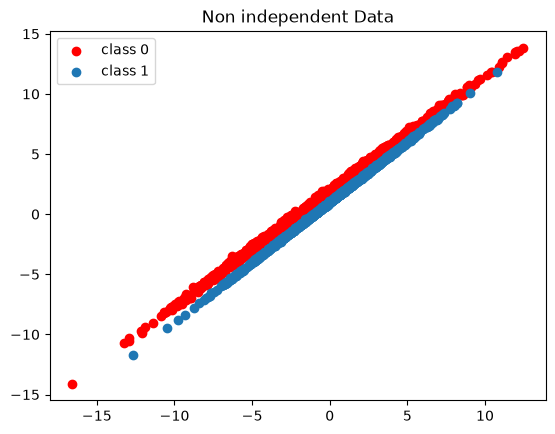

In [71]:
import numpy as np
import matplotlib.pyplot as plt
base_covar_0 = np.random.uniform(3, 4, (2,2))
base_covar_1 = np.random.uniform(2, 3, (2,2))
data_0 = np.concat([np.random.multivariate_normal([-1, 1], base_covar_0 @ base_covar_0.T, size=(1000)), np.zeros((1000, 1), dtype=int)], axis=1)
data_1 = np.concat([np.random.multivariate_normal([0, 1], base_covar_1 @ base_covar_1.T, size=(1000)), np.ones((1000, 1), dtype=int)], axis=1)
plt.scatter(data_0[:, 0], data_0[:, 1], c="red", label="class 0")
plt.scatter(data_1[:, 0], data_1[:, 1], label="class 1")
plt.legend()
plt.title("Non independent Data")
plt.show()


In [72]:
df = pd.DataFrame(
    np.concat([data_0, data_1], axis=0),
    columns=["Feature1", "Feature2", "Label"]
)
df.head()


,Feature1,Feature2,Label
0,-0.054958,1.976179,0.0
1,-6.672805,-4.263779,0.0
2,-4.441853,-2.041546,0.0
3,-4.751127,-2.672130,0.0
4,3.327413,5.021674,0.0


In [73]:
df_cmi = calculate_normalized_cmi(df)
df_cmi.style.background_gradient(cmap='Reds', axis=None).format("{:.3f}")

,Feature1,Feature2
Feature1,1.000,0.669
Feature2,0.669,1.000


We detect the the non-independent features here.

### Interpreting our generated data example
If our assumptions hold true we have calibrated probabilities:

In [74]:
columns = ["Binary1", "Binary2", "Binary3", "Gaussian1", "Gaussian2", "Gaussian3", "Multionimal1", "Multionimal2", "Multionimal3", "Multionimal4"]
data_to_inference = pd.DataFrame(columns=columns, data=np.array([
    [1, 0, 1, -3, 6, 0, 2, 0, 3, 5],
    [0, 1, 0, 3, -6, 0, 3, 5, 2, 0]
]))

model.predict(data_to_inference, return_probabilities=True)

array([[9.99998936e-01, 1.06360438e-06],
       [1.00000000e+00, 0.00000000e+00]])

We can look at importance or multiplicative effect of a variable on odds between classes:

In [75]:
model.binary_parameters["Binary1"]['class_1_p'] / model.binary_parameters["Binary1"]['class_0_p']

np.float64(3.6363636363636367)

Observing the first binary variable as true scales the odds of Class 1 vs. Class 0 by 3.36-fold (adding ln(3.36)≈1.21 to the log-odds). Starting from an uninformative 50% prior (prior odds of 1.0), the posterior probability increases to 77.1% (or ~75% when approximating as 3-fold).

**Feature Significance Testing**

We perform statistical hypothesis tests to determine whether our learned feature parameters capture genuine class separation or merely sample noise. For every test, our **Null Hypothesis ($H_0$)** is that the feature is **not significant** (the class-conditional distributions are identical across classes).

* **Binary Features ($2 \times 2$ $\chi^2$ Test of Independence):** We test whether class-specific success probabilities differ ($H_0: p_0 = p_1$). Expected counts ($E$) are calculated from pooled marginal frequencies under independence. By the Central Limit Theorem, the count deviations $(O - E)$ behave as zero-mean normal random variables; squaring them and scaling by $E$ yields a test statistic that asymptotically follows a $\chi^2$ distribution with $\text{df} = 1$:

$$\chi^2 = \sum_{i \in \{0,1\}} \sum_{j \in \{0,1\}} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$


* **Multinomial Features ($2 \times K$ $\chi^2$ Test of Homogeneity):** We generalize the contingency matrix to evaluate the entire count vector across all $K$ categories simultaneously ($2 \times 4$ in our model). This tests whether the overall category allocation vectors shift between classes ($H_0: \mathbf{p}_0 = \mathbf{p}_1$) with $\text{df} = K - 1$.
* **Gaussian Features (Welch's $t$-Test + Levene's Test):** Because our generative model estimates class-specific variances ($\sigma_0^2 \neq \sigma_1^2$), we use Welch’s two-sample $t$-test to determine whether class means differ without assuming equal spreads ($H_0: \mu_0 = \mu_1$). We pair this with Levene’s test (using medians for robustness against skew) to detect variance differences ($H_0: \sigma_0^2 = \sigma_1^2$), ensuring we capture features that separate classes by spread rather than center.

In [81]:
import numpy as np
import pandas as pd
from scipy import stats

def evaluate_model_significance(model_or_dict, df, alpha=0.05):
    params = model_or_dict if isinstance(model_or_dict, dict) else model_or_dict.__dict__
    label_col = params.get('label_column_name', 'Label')
    
    n_0 = int((df[label_col] == 0).sum())
    n_1 = int((df[label_col] == 1).sum())
    
    records = []

    # 1. Binary Features (2x2 Chi-Square Test of Independence)
    for col in params.get('binary_column_names', []):
        p0 = params['binary_parameters'][col]['class_0_p']
        p1 = params['binary_parameters'][col]['class_1_p']
        
        contingency = np.array([
            [p0 * n_0, (1.0 - p0) * n_0],
            [p1 * n_1, (1.0 - p1) * n_1]
        ])
        chi2, p_val, _, _ = stats.chi2_contingency(contingency, correction=False)
        
        records.append({
            "Feature": col,
            "Type": "Binary",
            "Parameters": f"p0={p0:.3f}, p1={p1:.3f}",
            "Test": "Chi-Square (2x2)",
            "Statistic": f"χ²={chi2:.2f}",
            "p-val (Mean/Prop)": p_val,
            "p-val (Variance)": np.nan,
            "Significant": p_val < alpha
        })

    # 2. Gaussian Features (Welch's t-Test for Means + Levene's Test for Variances)
    for col in params.get('gaussian_column_names', []):
        g_param = params['gaussian_parameters'][col]
        mu0, var0 = g_param['class_0_mean'], g_param['class_0_var']
        mu1, var1 = g_param['class_1_mean'], g_param['class_1_var']
        
        vals_0 = df.loc[df[label_col] == 0, col]
        vals_1 = df.loc[df[label_col] == 1, col]

        # Welch's t-test: H0: mu0 == mu1 (does not assume equal variance)
        t_stat, p_val_mean = stats.ttest_ind(vals_1, vals_0, equal_var=False)

        # Levene's test: H0: var0 == var1 (robust Brown-Forsythe formulation using median)
        w_stat, p_val_var = stats.levene(vals_0, vals_1, center='median')
        
        # Discriminative if EITHER the centers OR the spreads differ significantly
        is_significant = (p_val_mean < alpha) or (p_val_var < alpha)

        records.append({
            "Feature": col,
            "Type": "Gaussian",
            "Parameters": f"μ0={mu0:.2f}, μ1={mu1:.2f} | σ0²={var0:.2f}, σ1²={var1:.2f}",
            "Test": "Welch t + Levene",
            "Statistic": f"t={t_stat:.2f}, W={w_stat:.2f}",
            "p-val (Mean/Prop)": p_val_mean,
            "p-val (Variance)": p_val_var,
            "Significant": is_significant
        })

    # 3. Multinomial Features (2 x K Chi-Square Test of Homogeneity)
    multi_cols = params.get('multinomial_column_names', [])
    if multi_cols:
        contingency_multi = df.groupby(label_col)[multi_cols].sum().values
        chi2_multi, p_val_multi, dof, _ = stats.chi2_contingency(contingency_multi)
        
        records.append({
            "Feature": "Multinomial_Block",
            "Type": f"Multinomial ({len(multi_cols)} bins)",
            "Parameters": f"df={dof}",
            "Test": f"Chi-Square (2x{len(multi_cols)})",
            "Statistic": f"χ²={chi2_multi:.2f}",
            "p-val (Mean/Prop)": p_val_multi,
            "p-val (Variance)": np.nan,
            "Significant": p_val_multi < alpha
        })

    summary_df = pd.DataFrame(records).set_index("Feature")
    return summary_df

# Evaluate model and style significance results
significance_table = evaluate_model_significance(model, df_mixed)
significance_table.style.format({
    "p-val (Mean/Prop)": lambda x: f"{x:.3e}" if pd.notnull(x) else "-",
    "p-val (Variance)": lambda x: f"{x:.3e}" if pd.notnull(x) else "-"
}).apply(
    lambda col: ["background-color: #2e4d34" if v else "background-color: #5c2626" for v in col],
    subset=["Significant"]
)

,Type,Parameters,Test,Statistic,p-val (Mean/Prop),p-val (Variance),Significant
Feature,,,,,,,
Binary1,Binary,"p0=0.247, p1=0.900",Chi-Square (2x2),χ²=870.45,2.604e-191,-,True
Binary2,Binary,"p0=0.119, p1=0.247",Chi-Square (2x2),χ²=55.41,9.801e-14,-,True
Binary3,Binary,"p0=0.121, p1=0.693",Chi-Square (2x2),χ²=676.11,4.695e-149,-,True
Gaussian1,Gaussian,"μ0=-3.07, μ1=-1.71 | σ0²=26.06, σ1²=146.41",Welch t + Levene,"t=4.01, W=515.37",6.377e-05,1.081e-101,True
Gaussian2,Gaussian,"μ0=12.00, μ1=3.01 | σ0²=1.05, σ1²=0.04",Welch t + Levene,"t=-279.29, W=1001.73",0.000e+00,1.509e-178,True
Gaussian3,Gaussian,"μ0=4.00, μ1=6.01 | σ0²=0.09, σ1²=16.29",Welch t + Levene,"t=15.15, W=1393.14",6.803e-47,8.404e-232,True
Multinomial_Block,Multinomial (4 bins),df=3,Chi-Square (2x4),χ²=7619.04,0.000e+00,-,True


And finally we can also sample from the model:

In [82]:
import numpy as np
import pandas as pd

def sample_from_model(model_or_dict, target_class=1, n_samples=5, multinomial_trials=10, random_state=42):
    rng = np.random.default_rng(random_state)
    params = model_or_dict if isinstance(model_or_dict, dict) else model_or_dict.__dict__
    
    generated_data = {}
    
    # 1. Sample Binary Features: Bernoulli(p_c)
    binary_cols = params.get('binary_column_names', [])
    for col in binary_cols:
        p = params['binary_parameters'][col][f'class_{target_class}_p']
        generated_data[col] = rng.binomial(n=1, p=p, size=n_samples)
        
    # 2. Sample Gaussian Features: Normal(mu_c, sigma_c^2)
    gaussian_cols = params.get('gaussian_column_names', [])
    for col in gaussian_cols:
        g_param = params['gaussian_parameters'][col]
        mu = g_param[f'class_{target_class}_mean']
        var = g_param[f'class_{target_class}_var']
        std = np.sqrt(var)
        generated_data[col] = rng.normal(loc=mu, scale=std, size=n_samples)
        
    multinomial_cols = params.get('multinomial_column_names', [])
    if multinomial_cols:
        p_vec = np.array([
            params['multinomial_parameters'][col][f'p_{target_class}']
            for col in multinomial_cols
        ], dtype=float)
        p_vec /= p_vec.sum()
        
        multi_samples = rng.multinomial(n=multinomial_trials, pvals=p_vec, size=n_samples)
        for idx, col in enumerate(multinomial_cols):
            generated_data[col] = multi_samples[:, idx]

    df_samples = pd.DataFrame(generated_data)
    df_samples[params.get('label_column_name', 'Label')] = target_class
    
    return df_samples

# Generate synthetic observations conditioned on each class
samples_class_0 = sample_from_model(model, target_class=0, n_samples=3, multinomial_trials=10)
samples_class_1 = sample_from_model(model, target_class=1, n_samples=3, multinomial_trials=10)

pd.concat([samples_class_0, samples_class_1], ignore_index=True)

,Binary1,Binary2,Binary3,Gaussian1,Gaussian2,Gaussian3,Multionimal1,Multionimal2,Multionimal3,Multionimal4,Label
0,1,0,0,-7.422628,12.065165,3.747761,5,3,1,1,0
1,0,0,0,1.420491,13.151182,4.107925,3,2,4,1,0
2,1,1,0,0.901851,12.476029,3.718553,4,5,0,1,0
3,1,0,0,-12.027829,3.025670,2.546191,0,4,5,1,1
4,1,0,0,8.934557,3.234805,7.502089,0,6,3,1,1
5,1,1,1,7.705134,3.104790,2.144284,0,2,8,0,1


### Optimizing Generalization performance
Generalization error decomposes into bias and variance and irreducible error as explored in our repository's [root README](../../../../README.md).

* High Inductive Bias: Naive Bayes is characterized by strong inductive biases—primarily the conditional independence assumption, but also the choice of parametric likelihood families (e.g., Gaussian normality, Bernoulli trials). This structural rigidity makes the model resistant to overfitting, meaning it performs remarkably well on small sample sizes where complex models fail.
* Low Model Variance: Because parameters are estimated independently one feature at a time (1D marginals rather than a D-dimensional joint covariance matrix), parameter estimation variance is very low compared to full covariance models (like QDA).


Because Naive Bayes estimates 1-dimensional parameters independently for each feature ($O(D)$ parameters rather than a full $D \times D$ covariance matrix), its **estimation variance is inherently low**. Consequently, generalization error is almost entirely driven by **bias**.

To reduce underfitting and improve generalization, we target the two distinct sources of bias:

#### 1. Distributional Bias (1D Likelihood Misalignment)

* **The Problem:** Assuming an inappropriate parametric likelihood (e.g., forcing a skewed, strictly positive duration feature into a symmetric Gaussian distribution) distorts likelihood ratios, particularly in the distribution tails.
* **Remediation:**
* Inspect empirical marginal distributions (via histograms, Q-Q plots, or goodness-of-fit tests).
* Select likelihood families matching the feature's natural support (e.g., **Exponential/Log-Normal** for survival/latency, **Poisson** for unbounded event counts, **Bernoulli** for binary flags).
* Use non-parametric **Kernel Density Estimation (KDE)** if standard closed-form distributions fail to fit.



#### 2. Structural Bias (Conditional Independence Violations)

* **The Problem:** Highly correlated features duplicate evidence, causing the posterior log-odds to accumulate identical signals multiple times and producing overconfident, miscalibrated posteriors.
* **Remediation:**
* **Feature Pruning:** Drop redundant features flagged by elevated NCMI scores ($> 0.30$) or low statistical significance ($p \ge 0.05$).
* **Feature Synthesis:** Combine correlated pairs into single orthogonal metrics guided by domain knowledge (e.g., replacing `clicks` and `impressions` with a single `click_through_rate`, or applying PCA within feature subsets).
* **Model Escalation:** If domain constraints require preserving inter-feature dependencies, transition to architectures that relax strict independence (e.g., **Tree-Augmented Naive Bayes (TAN)**, **Logistic Regression**, or **QDA/Gaussian Discriminant Analysis**).

## Industry Standard Libraries

In production machine learning, introducing heavy third-party dependencies (such as JVM-based Spark clusters, black-box explainers, or CUDA-bound libraries) for Naive Bayes introduces unnecessary infrastructure overhead. Because Naive Bayes is an inherently additive, glass-box generative model, production-grade interpretability and web-scale training can be achieved using only `scipy` and `scikit-learn`.

## A High-Scale Problem

Let's apply Naive Bayes to a real-world dataset with mixed feature types (Binary, Gaussian, and Multinomial) at scale, using batch streaming (`partial_fit`) to evaluate generalization performance and parametric interpretability.

We are going to be looking at CIC UNSW-NB15 Augmented Dataset, that has normal and abnormal network traffic. See here: https://www.unb.ca/cic/datasets/cic-unsw-nb15.html. 

It uses features found from [CICFlowMeter tool](https://github.com/ahlashkari/CICFlowMeter/blob/master/ReadMe.txt).

Here's how to get the data:

**1. Download the File via Browser**

Follow the link to download the file at the bottom of https://www.unb.ca/cic/datasets/cic-unsw-nb15.html.
Download the CICFlowMeter_out.csv file.

**2. Place the Files into `.data/`**

Create the `.data` directory inside your notebook workspace and move the files:

```bash
# From this notebook location
mkdir -p .data

mv ~/Downloads/CICFlowMeter_out.csv .data/
```

This is a **hybrid testbed dataset** combining authentic background user traffic from the UNSW Canberra Cyber Range with attack traffic simulated via the IXIA PerfectStorm hardware stress-tester.

Traffic was transmitted across physical enterprise switches, captured via `tcpdump` into raw `.pcap` files, and subsequently parsed by a network forensic engines (University of New Brunswick's **CICFlowMeter**) to extract statistical **bidirectional network flow features**. 

In networking within TCP connections a network flow is a session thats defined by:

The 5-Tuple Identifier: Every packet assigned to the same flow must share the exact same five socket attributes:
* Source IP Address
* Destination IP Address
* Source Port
* Destination Port
* Transport Protocol (TCP, UDP, ICMP)
* (For bidirectional flows, forward [A→B] and backward [B→A] traffic are paired into one record).

Flow Termination Conditions: A flow boundary closes (generating a single row in the CSV) when either:
* Explicit Teardown: A TCP session completes via FIN or RST control flags.
* Flow Idle Timeout: No packet arrives within an inactivity threshold (e.g., 15 to 120 seconds).
* Maximum Active Timeout: A continuous connection exceeds an upper duration limit, forcing it to split into separate sub-flows.

The dataset provides two classification tasks:

* **Binary Classification:** Benign (`0`) vs. Malicious (`1`).
* **Multi-Class Classification:** Normal baseline (`0`) plus 9 distinct attack families (`1–9`: *Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode, Worms*).

Firstly let's sample and explore. Since it's tabular data and partial fits are available for this class of models in sci kit learn, we'll run this in a scalable way using pandas chunksize parameter that returns an iterator that reads only a specified amount of lines at a time.

In [1]:
import pandas as pd

def sample_scalable(path: str, chunksize=1e5, sample_pct: float = 0.01):
    stats = {
        "total_rows": 0,
        "sampled_rows": 0
    }
    reader = pd.read_csv(path, chunksize=chunksize)
    samples = []
    for batch in reader:
        samples.append(batch.sample(frac=sample_pct))
        stats["total_rows"] += batch.shape[0]
    samples = pd.concat(samples, axis=0)
    stats["sampled_rows"] = samples.shape[0]
    print(stats)
    return samples

sample_df = sample_scalable("./.data/CICFlowMeter_out.csv")

{'total_rows': 3540241, 'sampled_rows': 35402}


In [2]:
sample_df.head()

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
57680,59.166.0.6-149.171.126.0-51632-56621-6,59.166.0.6,51632,149.171.126.0,56621,6,22/01/2015 08:09:50 AM,355,1,2,...,32,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Benign
84591,59.166.0.2-149.171.126.2-24008-20655-17,59.166.0.2,24008,149.171.126.2,20655,17,22/01/2015 08:23:17 AM,1707,4,4,...,8,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Benign
49260,59.166.0.5-149.171.126.2-41002-3450-6,59.166.0.5,41002,149.171.126.2,3450,6,22/01/2015 08:13:39 AM,38131,62,63,...,32,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Benign
64410,59.166.0.7-149.171.126.2-43827-6881-6,59.166.0.7,43827,149.171.126.2,6881,6,22/01/2015 08:14:36 AM,329,1,2,...,32,0.0,0.000000,0.0,0.0,0.0,0.000000e+00,0.0,0.0,Benign
42751,59.166.0.3-149.171.126.7-54930-6881-6,59.166.0.3,54930,149.171.126.7,6881,6,22/01/2015 08:06:33 AM,29283590,486,903,...,32,2626942.5,158203.121475,2738809.0,2515076.0,11686319.5,4.989263e+06,15214261.0,8158378.0,Benign


In [3]:
sample_df.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [4]:
# lets start with this flow id:
(len(sample_df) - sample_df["Flow ID"].nunique()) , sample_df["Flow ID"].nunique()/ len(sample_df)

(144, 0.9959324331958647)

It's a bit odd we have ~142 duplicate flow ids though they accoutn for less than half a percent of our sample.

Maybe not though - given that a flow ID is uniquely defined by ports and ips and protocols, not time it could be such that two flows share an ID but occurred at different times with a termination in between that signaled a new flow.

Regardless, we wont consider the ID a generalizable feature since it's largely unique and a composite of others.

In [5]:
sample_df = sample_df.drop(columns="Flow ID")

In [6]:
sample_df["Src IP"].value_counts(normalize=True)[:5], sample_df["Dst IP"].value_counts(normalize=True)[:5]

(Src IP
 59.166.0.4    0.094119
 59.166.0.1    0.093611
 59.166.0.0    0.092311
 59.166.0.2    0.091887
 59.166.0.3    0.091690
 Name: proportion, dtype: float64,
 Dst IP
 149.171.126.2    0.096407
 149.171.126.7    0.093837
 149.171.126.5    0.091859
 149.171.126.1    0.091407
 149.171.126.4    0.090871
 Name: proportion, dtype: float64)

IPs are also a pretty sparse feature, and since they're largely auto assigned - just add risk to leakage rather improving generalization performance.

Src port cardinality: 26248


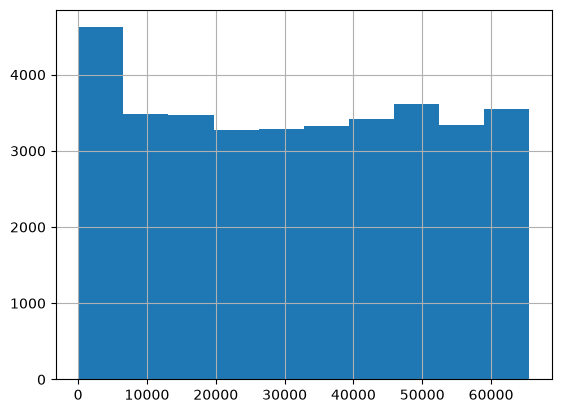

Dst Port cardinality: 26248


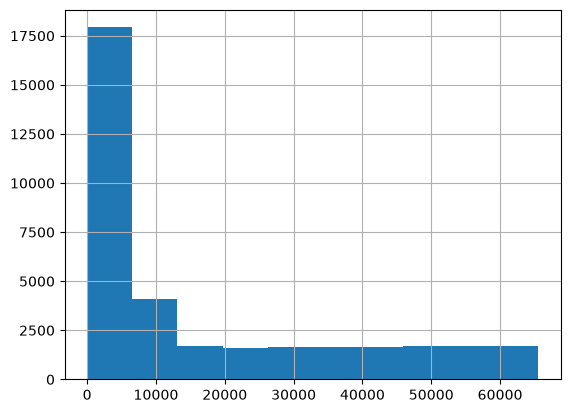

In [7]:
import matplotlib.pyplot as plt
sample_df["Src Port"].hist()
print(f"Src port cardinality: {sample_df['Src Port'].nunique()}")

plt.show()
sample_df["Dst Port"].hist()
print(f"Dst Port cardinality: {sample_df['Src Port'].nunique()}")

So ports may be useful to consider, though their cardinality is very large potentially larger than what may be useful.

Theres a Destination port difference though in that most of the mass in under port 5k, probably because those are where typical server services get traffic from.

There is a natural domain specific feature we can build here:

The Internet Assigned Numbers Authority (IANA) (see [here](https://datatracker.ietf.org/doc/html/rfc6335)) divides network port numbers into three main categories based on their function and assignment

* the System Ports, also known as the Well Known Ports, from 0-1023, usually require admin permission in operating system to bind since foundational services.
      (assigned by IANA)

* the User Ports, also known as the Registered Ports, from 1024-
      49151, specific vendor applications software or protocols - do not require admin permissions to use. (assigned by IANA)

* the Dynamic Ports, also known as the Private or Ephemeral Ports,
      from 49152-65535,used temporarily and at random for client outbound (never assigned)

So we could make a multinomial feature (factors in the mutual exclusivity of the categories, their non-independence, as a single feature in a way that supports the overall naive assumption).

For now we'll simply create a function to map to it's category and delete the old features.

In [8]:
def iana_range_mapper(val):
    if val < 1024:
        return "SYSTEM"
    elif val < 49152:
        return "USER"
    elif val < 65536 and val > 49151:
        return "DYNAMIC"
    else:
        return "INVALID"
def map_to_iana_ports_and_delete_ports(df: pd.DataFrame):
    df["Src_Port_IANA_Range"] = df["Src Port"].astype(int).apply(iana_range_mapper)
    df["Dst_Port_IANA_Range"] = df["Dst Port"].astype(int).apply(iana_range_mapper)
    df = df.drop(columns=["Src Port", "Dst Port"])
    return df

sample_df = map_to_iana_ports_and_delete_ports(sample_df)
sample_df["Src_Port_IANA_Range"].value_counts(), sample_df["Dst_Port_IANA_Range"].value_counts()

(Src_Port_IANA_Range
 USER       25852
 DYNAMIC     8721
 SYSTEM       829
 Name: count, dtype: int64,
 Dst_Port_IANA_Range
 USER       17272
 SYSTEM     13878
 DYNAMIC     4252
 Name: count, dtype: int64)

So mostly user and dynamic range for clients (sources) though its far more system for servers (destinations).

In [10]:
sample_df["Protocol"].value_counts(normalize=True)

Protocol
6     0.839727
17    0.160273
Name: proportion, dtype: float64

Protocol uses [IANA Protocol codes](https://www.iana.org/assignments/protocol-numbers) to specify, in our sample we see TCP (6) and UDP (17).

We'll probably consider this a multonimial with one trial to model the mutual exclusivity, particularly because there may be lower frequency values (vs a binary).

In [ ]:
sample_df["Timestamp"].value_counts(normalize=True)

Timestamp
22/01/2015 07:50:43 AM    0.000198
17/02/2015 08:52:06 PM    0.000169
22/01/2015 10:40:57 AM    0.000141
22/01/2015 12:42:14 PM    0.000141
22/01/2015 12:46:53 PM    0.000141
                            ...   
18/02/2015 08:06:26 AM    0.000028
18/02/2015 07:56:37 AM    0.000028
18/02/2015 08:23:10 AM    0.000028
18/02/2015 08:04:51 AM    0.000028
18/02/2015 07:57:31 AM    0.000028
Name: proportion, Length: 28911, dtype: float64

Timestamp is when flow started, but either way pretty useless feature for generalization, considering the dynamics however, we can use this to chronologically split our test/train split, ensuring we dont have leakage (an attack different IP but same attach that gets in both).

In [12]:
sample_df = sample_df.drop(columns=["Timestamp"])

In [40]:
(sample_df["Flow Duration"] / 1e6).describe()

count    35402.000000
mean         0.331459
std          2.361372
min          0.000001
25%          0.000343
50%          0.001201
75%          0.053378
max        119.849280
Name: Flow Duration, dtype: float64

Pretty wide range but they all look reasonable (described in seconds), we'll see how normal the duration in later.

In [21]:
## TODO: sample, do some EDA
## TODO: interperatability
## TODO: generalization performance optimization